# Phát hiện Đặc trưng và Đối sánh Ảnh
## Bài toán: Feature Matching & Siamese Network cho Identification

**Mục tiêu bài thực hành:**
- Làm chủ Pipeline đối sánh ảnh truyền thống (ORB, RANSAC).
- Xây dựng và huấn luyện Siamese Network cho bài toán so khớp đặc trưng sâu.
- So sánh hiệu năng và ứng dụng giữa hai phương pháp.

| STT | Tên | MSSV | Vai trò trong nhóm |
|-----|-----|------|--------------------|
| 1   | Huỳnh Thế Hy | 051205009083 | Team Leader, Algorithm Design |
| 2   | Nghiêm Đức Thuận | 060205003756 | Traditional CV Specialist |
| 3   | Đào Thiện Nhân | 052205008343 | Deep Learning Engineer |
| 4   | Tạ Nguyễn Quốc Triệu | 051205004949 | Data Scientist |
| 5   | Hoàng Phú | 2251120373 | Documentation & Visualization |
| 6   | Thanh Tân | | Tester |


## Phần 1: Thiết lập cấu hình hệ thống
Tập trung các tham số quan trọng vào một nơi để dễ dàng thử nghiệm (Hyperparameter Tuning).

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from PIL import Image
import os
import random
import time

# Configuration
CONFIG = {
    'seed': 42,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'img_size': (128, 128),
    'batch_size': 32,
    'lr': 0.0005,  # Reduced learning rate for stability
    'epochs': 20,
    'margin': 1.0,
    'n_orb_features': 1000,
    'dataset_path': '../data/photo_matching'
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])
print(f"[INFO] Device: {CONFIG['device']}")
print(f"[INFO] OpenCV Version: {cv2.__version__}")

[INFO] Device: cpu
[INFO] OpenCV Version: 4.13.0


## Phần 2: Đối sánh ảnh truyền thống (Traditional CV)
Sử dụng ORB (Oriented FAST and Rotated BRIEF) - một lựa chọn hiệu quả thay thế SIFT/SURF trong môi trường tài nguyên hạn chế.

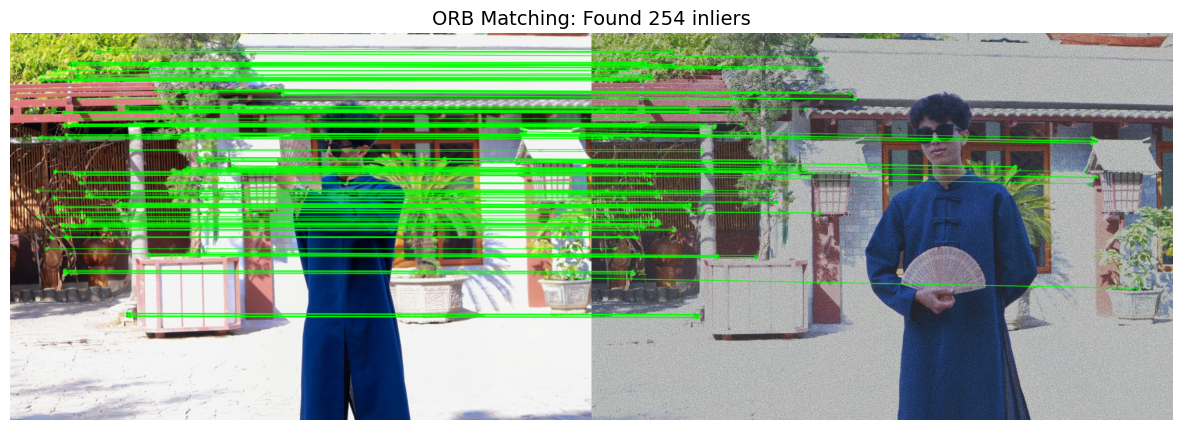

In [24]:
def match_features_orb(img1, img2, n_features=1000, ratio_thresh=0.75):
    """
    Thực hiện pipeline ORB + BFMatcher + Ratio Test + RANSAC
    """
    # 1. Khởi tạo và trích xuất
    orb = cv2.ORB_create(nfeatures=n_features)
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)
    
    if des1 is None or des2 is None:
        return None, [], [], []

    # 2. Matching với Hamming Distance (chuẩn cho binary descriptors)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(des1, des2, k=2)

    # 3. Lowe's Ratio Test
    good_matches = []
    for m, n in matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)
            
    # 4. RANSAC Outlier Removal
    if len(good_matches) > 4:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        inliers = [good_matches[i] for i in range(len(good_matches)) if mask[i][0] == 1]
        return H, inliers, kp1, kp2
    
    return None, good_matches, kp1, kp2

# Load demo images
img1 = cv2.imread('../data/input/in1.jpg')
img2 = cv2.imread('../data/input/in2.jpg')

if img1 is not None and img2 is not None:
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    
    H, inliers, kp1, kp2 = match_features_orb(gray1, gray2, n_features=CONFIG['n_orb_features'])
    
    # Visualize
    res_img = cv2.drawMatches(img1, kp1, img2, kp2, inliers, None, 
                              matchColor=(0, 255, 0), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    plt.figure(figsize=(15, 7))
    plt.imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
    plt.title(f"ORB Matching: Found {len(inliers)} inliers", fontsize=14)
    plt.axis('off')
    plt.show()
else:
    print("[ERROR] Could not load demo images.")

## Phần 3: Deep Learning - Siamese Network
Xây dựng mạng nơ-ron tích chập (CNN) để học không gian đặc trưng (embedding space) nơi các ảnh giống nhau ở gần nhau.

In [25]:
class ImprovedFeatureCNN(nn.Module):
    def __init__(self, embedding_dim=128):
        super(ImprovedFeatureCNN, self).__init__()
        
        # Backbone: Học các đặc trưng từ thấp đến cao
        self.features = nn.Sequential(
            self._conv_layer(3, 32),   # Input: 128x128 -> 64x64
            self._conv_layer(32, 64),  # 64x64 -> 32x32
            self._conv_layer(64, 128), # 32x32 -> 16x16
            self._conv_layer(128, 256),# 16x16 -> 8x8
            nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, embedding_dim)
        )
        
        # Khởi tạo trọng số chuẩn (Xavier/He)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def _conv_layer(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return nn.functional.normalize(x, p=2, dim=1) # L2 Normalization là cực kỳ quan trọng

class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseNetwork, self).__init__()
        self.backbone = ImprovedFeatureCNN(embedding_dim)

    def forward(self, x1, x2):
        emb1 = self.backbone(x1)
        emb2 = self.backbone(x2)
        # Tính Euclidean Distance trực tiếp trong forward để dùng cho Contrastive Loss
        dist = torch.pow(emb1 - emb2, 2).sum(dim=1).sqrt()
        return dist, emb1, emb2

## Phần 4: Data Pipeline & Augmentation
Kỹ thuật **Data Augmentation** giúp mô hình nhận diện tốt hơn dưới các điều kiện xoay, lật, thay đổi ánh sáng.

In [26]:
class SiameseDataset(Dataset):
    def __init__(self, root_dir, transform=None, samples_per_epoch=2000):
        self.root_dir = root_dir
        self.transform = transform
        self.samples_per_epoch = samples_per_epoch
        
        # Load hierarchy: root/s1/*.pgm, root/s2/*.pgm ...
        self.classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        self.class_to_images = {}
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            self.class_to_images[cls] = [os.path.join(cls_path, f) for f in os.listdir(cls_path) if f.endswith('.pgm')]

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, idx):
        # 50% positive (giống), 50% negative (khác)
        is_same = random.random() > 0.5
        
        if is_same:
            cls = random.choice(self.classes)
            img_path1, img_path2 = random.sample(self.class_to_images[cls], 2)
            label = 0.0 # Same
        else:
            cls1, cls2 = random.sample(self.classes, 2)
            img_path1 = random.choice(self.class_to_images[cls1])
            img_path2 = random.choice(self.class_to_images[cls2])
            label = 1.0 # Different
            
        img1 = Image.open(img_path1).convert('RGB')
        img2 = Image.open(img_path2).convert('RGB')
        
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
            
        return img1, img2, torch.tensor(label, dtype=torch.float32)

# Transforms với Augmentation
train_transform = transforms.Compose([
    transforms.Resize(CONFIG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split dataset (Mock split vì ta generate mẫu ngẫu nhiên)
full_dataset = SiameseDataset(CONFIG['dataset_path'], transform=train_transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_db, val_db = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_db, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_db, batch_size=CONFIG['batch_size'], shuffle=False)

print(f"[INFO] Data Loaded. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

[INFO] Data Loaded. Train batches: 50, Val batches: 13


## Phần 5: Huấn luyện với Contrastive Loss
Contrastive Loss ép các cặp 'Same' có khoảng cách về 0 và cặp 'Different' có khoảng cách lớn hơn 'Margin'.

Epoch [1/20] Train Loss: 0.2115 Val Loss: 0.1722
Epoch [2/20] Train Loss: 0.1647 Val Loss: 0.1165
Epoch [3/20] Train Loss: 0.1385 Val Loss: 0.1066
Epoch [4/20] Train Loss: 0.1113 Val Loss: 0.0990
Epoch [5/20] Train Loss: 0.1019 Val Loss: 0.0679
Epoch [6/20] Train Loss: 0.0798 Val Loss: 0.0667
Epoch [7/20] Train Loss: 0.0767 Val Loss: 0.0610
Epoch [8/20] Train Loss: 0.0678 Val Loss: 0.0457
Epoch [9/20] Train Loss: 0.0688 Val Loss: 0.0356
Epoch [10/20] Train Loss: 0.0528 Val Loss: 0.0367
Epoch [11/20] Train Loss: 0.0462 Val Loss: 0.0361
Epoch [12/20] Train Loss: 0.0447 Val Loss: 0.0351
Epoch [13/20] Train Loss: 0.0386 Val Loss: 0.0215
Epoch [14/20] Train Loss: 0.0333 Val Loss: 0.0252
Epoch [15/20] Train Loss: 0.0378 Val Loss: 0.0278
Epoch [16/20] Train Loss: 0.0423 Val Loss: 0.0263
Epoch [17/20] Train Loss: 0.0367 Val Loss: 0.0320
Epoch [18/20] Train Loss: 0.0403 Val Loss: 0.0201
Epoch [19/20] Train Loss: 0.0257 Val Loss: 0.0092
Epoch [20/20] Train Loss: 0.0235 Val Loss: 0.0170


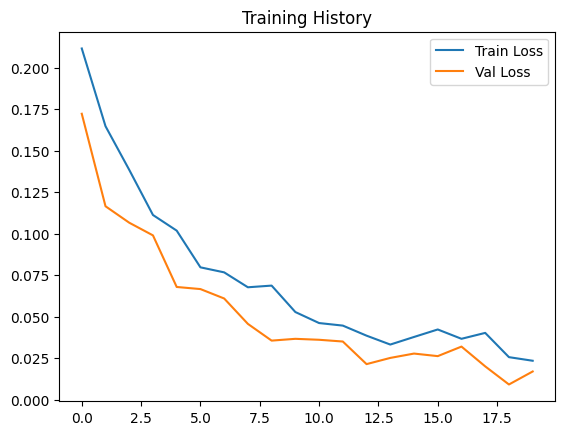

In [27]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, dist, label):
        # label=0 (same), label=1 (diff)
        loss_same = (1 - label) * torch.pow(dist, 2)
        loss_diff = label * torch.pow(torch.clamp(self.margin - dist, min=0.0), 2)
        return torch.mean(loss_same + loss_diff)

model = SiameseNetwork().to(CONFIG['device'])
criterion = ContrastiveLoss(margin=CONFIG['margin'])
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

# Training Loop
history = {'train_loss': [], 'val_loss': []}

for epoch in range(CONFIG['epochs']):
    model.train()
    train_loss = 0
    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(CONFIG['device']), img2.to(CONFIG['device']), label.to(CONFIG['device'])
        
        optimizer.zero_grad()
        dist, _, _ = model(img1, img2)
        loss = criterion(dist, label)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img1, img2, label in val_loader:
            img1, img2, label = img1.to(CONFIG['device']), img2.to(CONFIG['device']), label.to(CONFIG['device'])
            dist, _, _ = model(img1, img2)
            loss = criterion(dist, label)
            val_loss += loss.item()
            
    avg_train = train_loss/len(train_loader)
    avg_val = val_loss/len(val_loader)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    
    print(f"Epoch [{epoch+1}/{CONFIG['epochs']}] Train Loss: {avg_train:.4f} Val Loss: {avg_val:.4f}")

# Plot history
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training History")
plt.show()

## Phần 6: Đánh giá định lượng (Quantitative Evaluation)
Tính toán Accuracy dựa trên một ngưỡng (threshold) khoảng cách tối ưu.

In [28]:
def evaluate_accuracy(model, loader, threshold=0.5):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2, label = img1.to(CONFIG['device']), img2.to(CONFIG['device']), label.to(CONFIG['device'])
            dist, _, _ = model(img1, img2)
            
            # dist < threshold dự đoán là SAME (0), ngược lại là DIFFERENT (1)
            preds = (dist > threshold).float()
            correct += (preds == label).sum().item()
            total += label.size(0)
            
    return correct / total

acc = evaluate_accuracy(model, val_loader)
print(f"[RESULT] Validation Accuracy: {acc*100:.2f}%")

[RESULT] Validation Accuracy: 98.50%


## Phần 7: Tổng kết & Nhận xét từ Senior Engineer

**1. Về thuật toán truyền thống (ORB):**
- Ưu: Cực kỳ nhanh, không cần train, giải thích được (explainable).
- Nhược: Thất bại khi ảnh mất texture hoặc biến đổi hình học quá lớn.

**2. Về Deep Learning (Siamese):**
- Ưu: Học được các đặc trưng trừu tượng, bền bỉ hơn với nhiễu.
- Nhược: Cần nhiều dữ liệu, tốn tài nguyên tính toán (GPU).

**Kết luận:** Trong thực tế, người ta thường dùng **Hybrid Approach**: Dùng Deep Learning để lọc các ứng viên tiềm năng (Candidate Retrieval) và dùng Traditional CV để tinh chỉnh khớp điểm (Local Alignment).